# Price vs Points by Position — Playground #2

Given every player's **price** (`now_cost`) and **last-season total points** (`total_points`) from the FPL API, compare **value per position**.

**Metric**
- `price` = `now_cost / 10` (£m)
- `ppm` = **points per million** = `total_points / price` — higher is better value.

For each position (GKP / DEF / MID / FWD) we summarise `price`, `total_points`, and `ppm` using **max**, **p90**, and **median**.

Data: `https://fantasy.premierleague.com/api/bootstrap-static/` → `elements[x].now_cost`, `elements[x].total_points`.

Edit the **Config** cell, then *Run All*.

## Config — edit me

In [22]:
API_URL = "https://fantasy.premierleague.com/api/bootstrap-static/"

# Drop players who barely featured — they distort medians with lots of 0-point rows.
# Set to 0 to keep everyone.
MIN_POINTS = 1

# Aggregations to report per position.
P_QUANTILE = 0.90  # the "p90" column

POS_ORDER = ["GKP", "DEF", "MID", "FWD"]

## Fetch

In [23]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

resp = requests.get(API_URL, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)
resp.raise_for_status()
data = resp.json()

pos_map = {et["id"]: et["singular_name_short"] for et in data["element_types"]}
print(f"{len(data['elements'])} players fetched. Positions: {pos_map}")

555 players fetched. Positions: {1: 'GKP', 2: 'DEF', 3: 'MID', 4: 'FWD'}


## Build the table

In [24]:
df = pd.DataFrame(data["elements"])[["web_name", "element_type", "now_cost", "total_points"]]
df["pos"] = df["element_type"].map(pos_map)
df["price"] = df["now_cost"] / 10
df["ppm"] = np.where(df["price"] > 0, df["total_points"] / df["price"], np.nan)

df = df[df["total_points"] >= MIN_POINTS].copy()
df["pos"] = pd.Categorical(df["pos"], categories=POS_ORDER, ordered=True)
print(f"{len(df)} players after MIN_POINTS={MIN_POINTS} filter")
df.sort_values("ppm", ascending=False).head(10)

400 players after MIN_POINTS=1 filter


,web_name,element_type,now_cost,total_points,pos,price,ppm
202,Mitchell,2,45,135,DEF,4.5,30.000000
58,Truffert,2,55,165,DEF,5.5,30.000000
386,Guéhi,2,60,179,DEF,6.0,29.833333
494,Van Hecke,2,50,148,DEF,5.0,29.600000
500,Senesi,2,60,175,DEF,6.0,29.166667
105,Verbruggen,1,45,130,GKP,4.5,28.888889
79,Kelleher,1,50,143,GKP,5.0,28.600000
228,Tarkowski,2,60,170,DEF,6.0,28.333333
410,Anderson,3,65,180,MID,6.5,27.692308
54,Petrović,1,45,124,GKP,4.5,27.555556


## Summary per position — max / p90 / median

In [25]:
def summarise(col):
    g = df.groupby("pos", observed=True)[col]
    out = pd.DataFrame({
        "max": g.max(),
        "p90": g.quantile(P_QUANTILE),
        "median": g.median(),
    })
    return out.round(2)


for col, label in [("price", "Price (£m)"), ("total_points", "Total points"), ("ppm", "Points per £m")]:
    print(f"\n=== {label} ===")
    print(summarise(col))


=== Price (£m) ===
      max  p90  median
pos                   
GKP   6.0  5.5    5.00
DEF   8.0  5.5    4.75
MID  12.0  6.5    5.50
FWD  15.5  7.5    6.00

=== Total points ===
     max    p90  median
pos                    
GKP  162  135.0    91.0
DEF  209  136.0    70.0
MID  235  136.3    67.0
FWD  239  133.6    45.0

=== Points per £m ===
       max    p90  median
pos                      
GKP  28.89  27.20   19.20
DEF  30.00  25.65   14.67
MID  27.69  22.45   11.50
FWD  23.67  20.25    8.00


## Value leaders per position

Best points-per-million players in each position.

In [26]:
leaders = (
    df.sort_values("ppm", ascending=False)
      .groupby("pos", observed=True)
      .head(5)
      .loc[:, ["pos", "web_name", "price", "total_points", "ppm"]]
      .sort_values(["pos", "ppm"], ascending=[True, False])
      .round(2)
)
leaders

,pos,web_name,price,total_points,ppm
105,GKP,Verbruggen,4.5,130,28.89
79,GKP,Kelleher,5.0,143,28.60
54,GKP,Petrović,4.5,124,27.56
530,GKP,Roefs,5.0,136,27.20
248,GKP,Leno,4.5,122,27.11
202,DEF,Mitchell,4.5,135,30.00
58,DEF,Truffert,5.5,165,30.00
386,DEF,Guéhi,6.0,179,29.83
494,DEF,Van Hecke,5.0,148,29.60
500,DEF,Senesi,6.0,175,29.17


## Charts — points vs price per position

For each **price** point, aggregate `total_points` across the players at that price, separately per position. One line per position; three panels for **max**, **p90**, **median**.

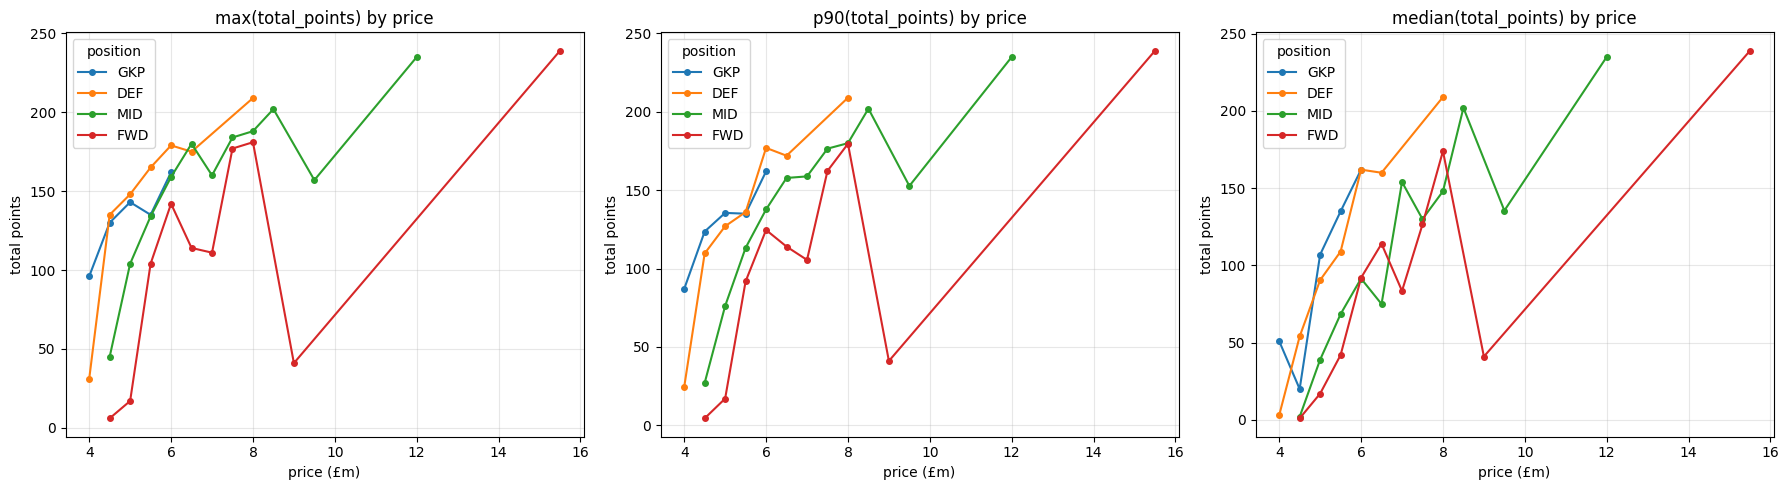

In [27]:
AGGS = {"max": "max", "p90": lambda s: s.quantile(P_QUANTILE), "median": "median"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for ax, (label, agg) in zip(axes, AGGS.items()):
    # points aggregated at each (position, price)
    grouped = (
        df.groupby(["pos", "price"], observed=True)["total_points"]
          .agg(agg)
          .rename("pts")
          .reset_index()
    )
    for pos in POS_ORDER:
        sub = grouped[grouped["pos"] == pos].sort_values("price")
        ax.plot(sub["price"], sub["pts"], marker="o", ms=4, label=pos)
    ax.set_title(f"{label}(total_points) by price")
    ax.set_xlabel("price (£m)")
    ax.set_ylabel("total points")
    ax.grid(True, alpha=0.3)
    ax.legend(title="position")

plt.tight_layout()
plt.show()

## Price brackets by points zone

Bucket players into `total_points` zones `[0-50, 50-100, 100-150, 150-200, 200-250]`, then per position report the **p90 of price** in each zone — i.e. roughly what you pay for a top-of-zone player. `max` and `median` shown alongside for context.

In [28]:
ZONE_EDGES = [0, 50, 100, 150, 200, 250]
ZONE_LABELS = ["0-50", "50-100", "100-150", "150-200", "200-250"]

dfz = df.copy()
dfz["points_zone"] = pd.cut(
    dfz["total_points"], bins=ZONE_EDGES, labels=ZONE_LABELS,
    right=False, include_lowest=True,
)

price_by_zone = (
    dfz.groupby(["pos", "points_zone"], observed=True)["price"]
       .agg(p90=lambda s: s.quantile(P_QUANTILE), max="max", median="median", n="count")
       .round(2)
       .reset_index()
)
price_by_zone

,pos,points_zone,p90,max,median,n
0,GKP,0-50,5.00,5.0,4.50,13
1,GKP,50-100,5.30,5.5,4.50,5
2,GKP,100-150,5.45,5.5,5.00,12
3,GKP,150-200,6.00,6.0,6.00,1
4,DEF,0-50,5.00,5.5,4.50,46
5,DEF,50-100,5.50,5.5,5.00,44
6,DEF,100-150,5.50,6.5,5.00,34
7,DEF,150-200,6.50,6.5,6.00,9
8,DEF,200-250,8.00,8.0,8.00,1
9,MID,0-50,5.50,6.5,5.00,74


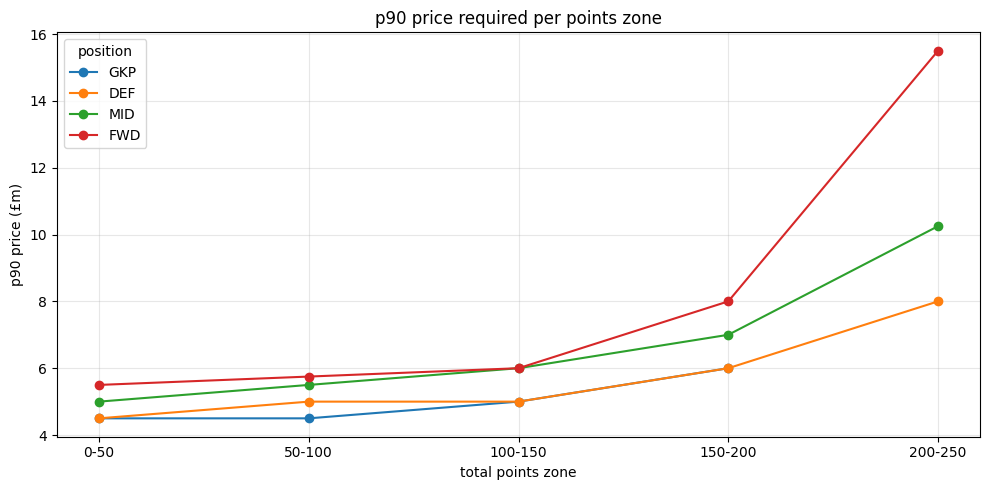

In [32]:
pivot = price_by_zone.pivot(index="points_zone", columns="pos", values="median").reindex(ZONE_LABELS)

fig, ax = plt.subplots(figsize=(10, 5))
for pos in POS_ORDER:
    if pos in pivot.columns:
        ax.plot(pivot.index, pivot[pos], marker="o", label=pos)
ax.set_title("p90 price required per points zone")
ax.set_xlabel("total points zone")
ax.set_ylabel("p90 price (£m)")
ax.grid(True, alpha=0.3)
ax.legend(title="position")
plt.tight_layout()
plt.show()

## 5-bucket price structure

Turn the five points zones into five per-position price buckets, using the **p90 price** of each zone (rounded to the nearest £0.5 FPL step). Zones with no players are forward-filled from the zone below. Position keys use `GK` to match the formation-builder format.

In [34]:
# 5 buckets = the 5 points zones, valued at the p90 price of each zone.
KEY_MAP = {"GKP": "GK", "DEF": "DEF", "MID": "MID", "FWD": "FWD"}


def round_half(x):
    return round(x * 2) / 2


PRICES = {}
for pos in POS_ORDER:
    row = (
        price_by_zone[price_by_zone["pos"] == pos]
        .set_index("points_zone")
        .reindex(ZONE_LABELS)["p90"]
    )
    row = row.ffill().bfill()  # fill empty zones from neighbours
    buckets = [round_half(v) for v in row]
    PRICES[KEY_MAP[pos]] = buckets

# Pretty-print in the target format with a min-max range comment.
print("PRICES = {")
for pos in POS_ORDER:
    key = KEY_MAP[pos]
    b = PRICES[key]
    lo, hi = min(b), max(b)
    print(f'    "{key}":'.ljust(12) + f"{b},".ljust(30) + f"# {lo} - {hi}")
print("}")

PRICES = {
    "GK":   [5.0, 5.5, 5.5, 6.0, 6.0],    # 5.0 - 6.0
    "DEF":  [5.0, 5.5, 5.5, 6.5, 8.0],    # 5.0 - 8.0
    "MID":  [5.5, 6.5, 7.5, 8.0, 11.5],   # 5.5 - 11.5
    "FWD":  [6.0, 6.5, 7.5, 8.0, 15.5],   # 6.0 - 15.5
}
